## Import

In [2]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV 

from sklearn.metrics import make_scorer
from ML.utils.utils import max_error_single, gaussian

import pandas as pd

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler

In [4]:
pre_path = "../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/fine_tuned_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/fine_tuned_models/"
output_parameters = ["mass", "radius"]
categories_name = ["phase"]
scoring = ["neg_root_mean_squared_error", "neg_mean_absolute_error"] # RMSE and MAE
max_err_scorer = make_scorer(max_error_single, greater_is_better=False)

In [5]:
override = True
use_preds = False
save = True
show = True

In [6]:
def display_grid_search(gscv):
    df = pd.DataFrame.from_dict(gscv.cv_results_)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    display(df)
    print(f"Best parameters {gscv.best_params_}")
    print(f"Best score {gscv.best_score_}")

## Data preparation

In [7]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


In [8]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})

In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

In [10]:
X_train_standard, X_ivs_standard = Data_preparator.scale_data(X_train, X_ivs, "standard")

print(X_train_standard.shape, X_ivs_standard.shape)

(389468, 4) (129823, 4)


# Faire le fine-tuning

Random forest with scale_standard_14 and KNN with scale_standard_14

## Fine-tuning

### Random forest

In [16]:
tag = "scale_standard_14"

#### Tuning the n_estimators and criterion parameters

In [ ]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 400, 600]
            }

gscv_rmse = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   9.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.3s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.5s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.2s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.8s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.2s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   9.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.4s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  17.3s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,8.591151,0.353608,0.152454,0.011274,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.018460,-0.018449,-0.019328,-0.018471,-0.020321,-0.018600,-0.019359,-0.018701,-0.018995,-0.018765,-0.018945,0.000560,5,-0.007139,-0.007103,-0.007175,-0.006956,-0.007271,-0.007074,-0.007063,-0.007120,-0.007051,-0.007135,-0.007109,0.000079,5
1,17.101856,0.347285,0.274158,0.010180,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.018197,-0.018609,-0.018952,-0.018298,-0.019520,-0.018388,-0.018928,-0.018459,-0.018667,-0.018426,-0.018644,0.000376,4,-0.006992,-0.006978,-0.007016,-0.006827,-0.007125,-0.006904,-0.006867,-0.006988,-0.006897,-0.006992,-0.006959,0.000082,4
2,32.812815,0.675379,0.648971,0.284320,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.017992,-0.018479,-0.018707,-0.018062,-0.019408,-0.018199,-0.019043,-0.018248,-0.018691,-0.018293,-0.018512,0.000429,3,-0.006870,-0.006889,-0.006936,-0.006717,-0.007012,-0.006811,-0.006783,-0.006886,-0.006790,-0.006901,-0.006860,0.000081,3
3,67.221820,1.327724,32.176583,1.540765,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.017919,-0.018299,-0.018762,-0.018009,-0.019296,-0.018156,-0.018951,-0.018168,-0.018655,-0.018212,-0.018443,0.000427,2,-0.006859,-0.006855,-0.006887,-0.006677,-0.006964,-0.006784,-0.006742,-0.006849,-0.006751,-0.006858,-0.006823,0.000079,2
4,99.291862,5.006113,72.035918,2.589549,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.017873,-0.018387,-0.018720,-0.017889,-0.019273,-0.018180,-0.018820,-0.018181,-0.018560,-0.018200,-0.018408,0.000417,1,-0.006819,-0.006854,-0.006870,-0.006648,-0.006965,-0.006766,-0.006711,-0.006825,-0.006733,-0.006854,-0.006804,0.000087,1
5,8.487312,0.414046,0.147279,0.010545,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.019492,-0.019875,-0.020114,-0.018957,-0.021199,-0.019813,-0.020361,-0.020143,-0.019965,-0.020416,-0.020034,0.000562,10,-0.007678,-0.007651,-0.007699,-0.007405,-0.007734,-0.007584,-0.007577,-0.007706,-0.007636,-0.007630,-0.007630,0.000089,10
6,15.413902,0.424673,0.272287,0.009118,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.019049,-0.019175,-0.019933,-0.018592,-0.021114,-0.019778,-0.020013,-0.019552,-0.019910,-0.020275,-0.019739,0.000668,9,-0.007474,-0.007443,-0.007570,-0.007219,-0.007552,-0.007441,-0.007386,-0.007480,-0.007421,-0.007470,-0.007446,0.000092,9
7,29.169554,0.840563,0.516206,0.009500,friedman_mse,200,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.019038,-0.018980,-0.019807,-0.018531,-0.020962,-0.019555,-0.019855,-0.019431,-0.019688,-0.019878,-0.019573,0.000626,8,-0.007435,-0.007330,-0.007410,-0.007157,-0.007473,-0.007316,-0.007279,-0.007361,-0.007304,-0.007347,-0.007341,0.000085,8
8,59.169674,1.035958,20.861437,2.939406,friedman_mse,400,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.018967,-

Best parameters {'criterion': 'squared_error', 'n_estimators': 600}
Best score -0.0184081938069038


In [ ]:
cv_params = {'criterion' : ["squared_error", "friedman_mse"], # absolute_error prend beaucoup de temps et poisson n'est pas possible avec des valeurs négatives
             'n_estimators' : [50, 100, 200, 400, 600]
            }

gscv_max_er = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.3s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.5s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.1s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.0s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   8.0s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.3s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.3s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.9s
[CV] END ...........criterion=squared_error, n_estimators=50; total time=   7.1s
[CV] END ..........criterion=squared_error, n_estimators=100; total time=  15.2s
[CV] END ..........criterion=squared_error, n_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,7.696800,0.372456,0.140659,0.014518,squared_error,50,"{'criterion': 'squared_error', 'n_estimators':...",-0.886268,-0.968870,-1.029546,-1.422516,-1.302545,-1.475275,-1.890277,-1.467368,-2.303646,-0.905826,-1.365214,0.435464,6
1,14.911318,0.303417,0.253450,0.007412,squared_error,100,"{'criterion': 'squared_error', 'n_estimators':...",-0.764844,-1.056293,-1.415667,-1.343055,-1.293359,-1.510673,-1.907648,-1.467218,-2.433132,-0.957340,-1.414923,0.455189,9
2,28.413556,0.391162,0.492755,0.008186,squared_error,200,"{'criterion': 'squared_error', 'n_estimators':...",-0.762544,-1.113868,-1.152221,-1.436798,-1.683338,-1.430485,-1.890830,-1.466867,-2.395086,-1.074493,-1.440653,0.442401,10
3,57.083192,0.942898,11.246961,2.250245,squared_error,400,"{'criterion': 'squared_error', 'n_estimators':...",-0.751954,-1.004637,-1.098417,-1.417021,-1.458622,-1.465375,-1.910687,-1.466783,-2.365733,-0.915337,-1.385457,0.458902,7
4,85.638431,1.173322,23.687699,0.692125,squared_error,600,"{'criterion': 'squared_error', 'n_estimators':...",-0.787837,-0.849672,-1.092120,-1.369910,-1.658108,-1.456086,-1.912843,-1.466776,-2.337521,-1.046071,-1.397694,0.459858,8
5,7.590285,0.312376,0.133316,0.007073,friedman_mse,50,"{'criterion': 'friedman_mse', 'n_estimators': 50}",-0.891993,-0.758812,-0.940160,-1.162616,-1.540687,-1.278253,-1.901967,-1.478948,-2.229720,-1.264024,-1.344718,0.436598,4
6,14.329147,0.394946,0.242702,0.004324,friedman_mse,100,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.733203,-0.973001,-0.939671,-1.352018,-1.588922,-1.060778,-1.878993,-1.473012,-2.306861,-1.234769,-1.354123,0.453358,5
7,28.384225,0.673091,0.484448,0.019008,friedman_mse,200,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.733345,-0.855630,-1.009870,-0.984586,-1.478096,-1.220709,-1.885488,-1.471875,-2.326310,-1.156708,-1.312262,0.467430,1
8,58.201945,1.433396,12.456569,3.467426,friedman_mse,400,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.763209,-0.781461,-1.073620,-0.979797,-1.492814,-1.290230,-1.898034,-1.469609,-2.283865,-1.153978,-1.318662,0.460469,3
9,87.570575,1.372513,24.401869,1.877842,friedman_mse,600,"{'criterion': 'friedman_mse', 'n_estimators': ...",-0.772378,-0.766870,-1.080147,-1.030490,-1.498226,-1.261097,-1.869299,-1.464550,-2.266977,-1.145603,-1.315564,0.450780,2


Best parameters {'criterion': 'friedman_mse', 'n_estimators': 200}
Best score -1.3122617116147128


Best parameters {'criterion': 'squared_error', 'n_estimators': 600} (squared_error better than friedman_mse, more estimators mean better results)

Best RMSE -0.0184081938069038

Best parameters {'criterion': 'friedman_mse', 'n_estimators': 200} (friedman_mse better than squared_error, more estimators does not always mean better results)

Best MAX_ER -1.3122617116147128

chosen parameters : {'criterion': 'friedman_mse', 'n_estimators': 600}

#### Tuning the max_depth, min_samples_split and min_samples_leaf parameters

In [12]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_rmse = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100, # results with 600 are better but take more time, doing gridsearchcv with 100 is comparable to 600
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  16.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  16.8s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.5s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.0s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.6s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=  15.5s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,16.955530,0.320706,0.279126,0.016246,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.018982,-0.019157,-0.019832,-0.018592,-0.021439,-0.019503,-0.019962,-0.019554,-0.019747,-0.020065,-0.019683,0.000731,1,-0.007451,-0.007444,-0.007525,-0.007214,-0.007579,-0.007375,-0.007389,-0.007475,-0.007417,-0.007475,-0.007434,0.000094,1
1,15.044212,0.251179,0.191949,0.007456,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.021788,-0.021673,-0.022351,-0.021210,-0.023684,-0.022358,-0.022250,-0.022110,-0.022330,-0.022588,-0.022234,0.000620,5,-0.009110,-0.008999,-0.009098,-0.008780,-0.009113,-0.008976,-0.008922,-0.009026,-0.009003,-0.009033,-0.009006,0.000095,6
2,14.337254,0.191741,0.156202,0.006605,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.024981,-0.024692,-0.025489,-0.023976,-0.026365,-0.025214,-0.025320,-0.025271,-0.025160,-0.025468,-0.025194,0.000578,15,-0.010941,-0.010792,-0.010909,-0.010496,-0.010880,-0.010747,-0.010719,-0.010861,-0.010776,-0.010790,-0.010791,0.000120,13
3,14.492902,0.138424,0.193195,0.004986,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.022909,-0.022979,-0.025206,-0.022639,-0.025325,-0.023979,-0.023564,-0.023475,-0.023404,-0.024702,-0.023818,0.000910,10,-0.009579,-0.009514,-0.009704,-0.009263,-0.009586,-0.009519,-0.009444,-0.009624,-0.009496,-0.009537,-0.009527,0.000112,8
4,14.286030,0.175992,0.185884,0.008281,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.023390,-0.022983,-0.025156,-0.022545,-0.025181,-0.023826,-0.023482,-0.023353,-0.023234,-0.024865,-0.023802,0.000890,9,-0.009671,-0.009539,-0.009705,-0.009268,-0.009597,-0.009471,-0.009407,-0.009604,-0.009480,-0.009545,-0.009529,0.000122,10
5,13.972764,0.196987,0.159375,0.014508,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.025877,-0.025489,-0.027750,-0.025190,-0.027173,-0.026361,-0.025944,-0.025789,-0.025687,-0.027426,-0.026269,0.000834,16,-0.011254,-0.011085,-0.011265,-0.010799,-0.011081,-0.011039,-0.010972,-0.011157,-0.011050,-0.011101,-0.011080,0.000128,18
6,13.557940,0.395068,0.148118,0.011019,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.027372,-0.027271,-0.029029,-0.026764,-0.029528,-0.028290,-0.027700,-0.027442,-0.027270,-0.029139,-0.027980,0.000903,24,-0.011994,-0.011824,-0.011970,-0.011477,-0.011894,-0.011819,-0.011749,-0.011912,-0.011721,-0.011837,-0.011820,0.000141,26
7,13.666532,0.252437,0.143303,0.006200,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.027277,-0.027586,-0.029014,-0.026691,-0.029396,-0.028303,-0.027754,-0.027327,-0.027159,-0.028809,-0.027932,0.000855,20,-0.011981,-0.011844,-0.011924,-0.011507,-0.011842,-0.011750,-0.011683,-0.011896,-0.011791,-0.011748,-0.011797,0.000129,19
8,13.389609,0.574279,0.150322,0.014469,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-0.027272,-0.027429,-0.029104,-0.026613,-0.029514,-0.028314,-0.027

Best parameters {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -0.019683282169575215


In [13]:
cv_params = {'max_depth' : [50, 100, None],
             'min_samples_split' : [2, 6, 10],
             'min_samples_leaf' : [1, 3, 5],
            }

gscv_max_er = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100, # results with 600 are better but take more time, doing gridsearchcv with 100 is comparable to 600
                                            ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 27 candidates, totalling 270 fits
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.2s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  16.4s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  16.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.1s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.4s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.4s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.6s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.4s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.7s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=2; total time=  17.3s
[CV] END max_depth=50, min_samples_leaf=1, min_samples_split=6; total time=  15.2s
[CV] END max_depth=50, m

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,16.966877,0.506958,0.281040,0.011875,50,1,2,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.732849,-0.819964,-1.078520,-1.305881,-1.607259,-1.176678,-1.919071,-1.469999,-2.328842,-1.090117,-1.352918,0.468776,4
1,14.997531,0.245569,0.197548,0.008277,50,1,6,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-0.783787,-0.802555,-1.016588,-1.035715,-1.483359,-1.289760,-1.851040,-1.469980,-2.252395,-1.071678,-1.305686,0.446007,2
2,14.322237,0.237082,0.154459,0.004351,50,1,10,"{'max_depth': 50, 'min_samples_leaf': 1, 'min_...",-1.018672,-0.893657,-1.142385,-1.145722,-1.483965,-1.236217,-1.836325,-1.479732,-2.180877,-1.191279,-1.360883,0.374361,6
3,13.901832,0.189267,0.175419,0.007026,50,3,2,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.937521,-0.975574,-2.431177,-1.754864,-1.586215,-1.354710,-1.720017,-1.467920,-2.176265,-2.020776,-1.642504,0.461183,12
4,13.197492,0.378177,0.183103,0.012901,50,3,6,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-0.884866,-1.058958,-2.198610,-2.013862,-1.545289,-1.414979,-1.748512,-1.463251,-2.150433,-2.061403,-1.654016,0.435710,15
5,13.458384,0.468171,0.146799,0.011533,50,3,10,"{'max_depth': 50, 'min_samples_leaf': 3, 'min_...",-1.075392,-0.984426,-2.384419,-1.676267,-1.674968,-1.609479,-1.956805,-1.461015,-2.182199,-2.130610,-1.713558,0.438082,18
6,13.597122,0.369790,0.149555,0.012394,50,5,2,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-1.089465,-1.157871,-2.113688,-2.253531,-1.699574,-1.732472,-1.931755,-1.412277,-2.022915,-2.420647,-1.783420,0.428457,24
7,13.065925,0.206812,0.143936,0.009645,50,5,6,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-1.098456,-1.281729,-2.198888,-2.134553,-1.539138,-1.797725,-1.868890,-1.463151,-2.014154,-2.130496,-1.752718,0.367533,19
8,13.410432,0.236341,0.154287,0.020032,50,5,10,"{'max_depth': 50, 'min_samples_leaf': 5, 'min_...",-1.109157,-1.242163,-2.144086,-2.110175,-1.586670,-1.959624,-1.988151,-1.457133,-1.947271,-2.286011,-1.783044,0.384970,23
9,16.193998,0.440784,0.261764,0.014327,100,1,2,"{'max_depth': 100, 'min_samples_leaf': 1, 'min...",-0.732980,-0.740683,-1.031912,-0.989594,-1.572343,-1.305336,-1.878528,-1.467771,-2.256309,-1.046372,-1.302183,0.471001,1


Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best score -1.3021828511765465


Best parameters {'max_depth': 50, 'min_samples_leaf': 1, 'min_samples_split': 2} ('max_depth' : 100/None also works fine)

Best RMSE -0.019683282169575215

Best parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}

Best MAX_ER -1.3021828511765465

chosen parameters {'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2}

#### Tuning the max_features and max_leaf_nodes parameters

In [14]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [50, 100, 200, None]
            }

gscv_rmse = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=1,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.5s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.6s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.1s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   3.9s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.3s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.1s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.7s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.9s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   5.0s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,4.420980,0.294145,0.047395,0.013033,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-0.252188,-0.253911,-0.248689,-0.248288,-0.253150,-0.252172,-0.251472,-0.255671,-0.250970,-0.250187,-0.251670,0.002163,10,-0.162473,-0.165176,-0.163238,-0.162125,-0.162207,-0.165148,-0.165089,-0.168866,-0.163674,-0.162472,-0.164047,0.001991,11
1,4.918014,0.102883,0.044351,0.008495,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-0.181571,-0.176992,-0.181577,-0.182796,-0.180017,-0.177880,-0.175299,-0.181402,-0.179309,-0.180529,-0.179737,0.002246,7,-0.116168,-0.113509,-0.115864,-0.116291,-0.114025,-0.114891,-0.112355,-0.116353,-0.115005,-0.116144,-0.115061,0.001306,7
2,5.380620,0.179386,0.047460,0.007616,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-0.132225,-0.131232,-0.130646,-0.132848,-0.129804,-0.130946,-0.130628,-0.130511,-0.132199,-0.130898,-0.131194,0.000893,5,-0.083649,-0.084119,-0.082682,-0.083483,-0.082734,-0.083305,-0.083610,-0.083383,-0.084107,-0.082713,-0.083379,0.000507,4
3,10.238351,0.280633,0.286462,0.028103,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.018831,-0.018562,-0.019191,-0.018369,-0.019513,-0.018380,-0.019143,-0.018446,-0.018967,-0.019290,-0.018869,0.000393,2,-0.007313,-0.007270,-0.007258,-0.007043,-0.007336,-0.007186,-0.007123,-0.007296,-0.007218,-0.007260,-0.007230,0.000086,2
4,4.460935,0.259445,0.041413,0.006699,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-0.255339,-0.255060,-0.250010,-0.247700,-0.252385,-0.247716,-0.250358,-0.256476,-0.251500,-0.250728,-0.251727,0.002921,11,-0.164083,-0.165727,-0.162777,-0.159219,-0.165150,-0.163175,-0.164027,-0.166003,-0.162091,-0.163232,-0.163548,0.001886,10
5,4.865283,0.108385,0.047246,0.015370,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-0.180590,-0.182935,-0.182438,-0.181279,-0.179212,-0.174760,-0.178269,-0.180110,-0.177907,-0.181628,-0.179913,0.002336,8,-0.113605,-0.118073,-0.115958,-0.114499,-0.114180,-0.111352,-0.114655,-0.115186,-0.113644,-0.116830,-0.114798,0.001774,6
6,5.308737,0.121009,0.052823,0.011112,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-0.132888,-0.129215,-0.132045,-0.132466,-0.130446,-0.128495,-0.128958,-0.133202,-0.128047,-0.131122,-0.130688,0.001826,4,-0.083920,-0.082716,-0.083689,-0.083882,-0.083067,-0.083142,-0.082300,-0.086102,-0.081709,-0.083342,-0.083387,0.001123,5
7,9.899043,0.259281,0.262422,0.013014,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.018539,-0.018802,-0.019219,-0.018471,-0.019077,-0.018154,-0.018835,-0.018461,-0.019052,-0.019124,-0.018773,0.000335,1,-0.007254,-0.007281,-0.007305,-0.007091,-0.007298,-0.007107,-0.007131,-0.007269,-0.007231,-0.007260,-0.007223,0.000077,1
8,7.464709,0.156124,0.046645,0.012607,None,50,"{'max_features': None, 'max_leaf_nodes': 50}",-0.333543,-0.323105,-0.332991,-0.322082,-0.323179,-0.325241,-0.328468,-0.332461,-0.331211,-0.325474,-0.327775,

Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}
Best score -0.01877334511453264


In [15]:
cv_params = {"max_features" : ["sqrt", "log2", None], 
             "max_leaf_nodes" : [50, 100, 200, None]
            }

gscv_max_er = GridSearchCV(RandomForestRegressor(n_jobs = 10,
                                             criterion="friedman_mse",
                                             n_estimators=100,
                                             max_depth=100,
                                             min_samples_leaf=1,
                                             min_samples_split=2
                                            ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit=True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 12 candidates, totalling 120 fits
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.6s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.4s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.2s
[CV] END ...............max_features=sqrt, max_leaf_nodes=50; total time=   4.1s
[CV] END ..............max_features=sqrt, max_leaf_nodes=100; total time=   4.7s
[CV] END ..............max_features=sqrt, max_

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_features,param_max_leaf_nodes,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,4.311496,0.126839,0.048572,0.015303,sqrt,50,"{'max_features': 'sqrt', 'max_leaf_nodes': 50}",-3.116547,-3.222899,-3.209430,-3.421988,-3.482723,-2.839193,-3.367011,-3.079687,-3.247982,-2.951702,-3.193916,0.193112,9
1,4.613680,0.106121,0.051143,0.013610,sqrt,100,"{'max_features': 'sqrt', 'max_leaf_nodes': 100}",-2.569884,-2.848878,-2.892315,-2.952068,-2.975728,-2.640530,-2.515664,-2.694251,-2.720349,-2.904845,-2.771451,0.156370,8
2,5.039908,0.176516,0.049174,0.012261,sqrt,200,"{'max_features': 'sqrt', 'max_leaf_nodes': 200}",-2.301405,-2.417613,-2.539708,-2.475438,-2.493492,-2.198270,-2.201394,-2.476720,-2.193654,-2.789739,-2.408743,0.179921,4
3,9.892228,0.463427,0.272313,0.016865,sqrt,None,"{'max_features': 'sqrt', 'max_leaf_nodes': None}",-0.852119,-0.754898,-1.334578,-1.336006,-1.011851,-0.949770,-1.867743,-1.453037,-1.667103,-1.231647,-1.245875,0.340854,1
4,4.319497,0.054183,0.108976,0.183623,log2,50,"{'max_features': 'log2', 'max_leaf_nodes': 50}",-3.255069,-3.312590,-3.271872,-3.143876,-3.165303,-3.228346,-3.450200,-2.949912,-3.200014,-2.990966,-3.196815,0.139560,10
5,4.887608,0.088948,0.051590,0.009984,log2,100,"{'max_features': 'log2', 'max_leaf_nodes': 100}",-2.546257,-2.799192,-2.892562,-2.765222,-2.788548,-2.551578,-2.583943,-2.692741,-2.636078,-2.996081,-2.725220,0.142685,7
6,5.521528,0.300918,0.054197,0.012608,log2,200,"{'max_features': 'log2', 'max_leaf_nodes': 200}",-2.222879,-2.527559,-2.651087,-2.486090,-2.480944,-2.277308,-2.452644,-2.349765,-2.292781,-2.833504,-2.457456,0.176468,5
7,10.094091,0.266370,0.274944,0.008957,log2,None,"{'max_features': 'log2', 'max_leaf_nodes': None}",-0.756350,-0.809548,-1.420154,-1.815014,-0.968550,-0.934752,-1.835771,-1.423702,-1.662972,-1.560217,-1.318703,0.394633,2
8,7.900815,0.306642,0.044485,0.008029,None,50,"{'max_features': None, 'max_leaf_nodes': 50}",-3.942766,-4.082787,-4.066469,-3.924427,-4.376109,-4.264180,-3.817146,-3.878258,-4.504122,-4.074572,-4.093084,0.212795,12
9,8.570189,0.191897,0.046133,0.008976,None,100,"{'max_features': None, 'max_leaf_nodes': 100}",-3.244105,-3.659482,-3.282979,-2.980488,-2.984245,-3.505511,-3.169941,-3.253470,-3.493209,-2.959730,-3.253316,0.229579,11


Best parameters {'max_features': 'sqrt', 'max_leaf_nodes': None}
Best score -1.2458752562863538


Best parameters {'max_features': 'log2', 'max_leaf_nodes': None}

Best RMSE -0.01877334511453264

Best parameters {'max_features': 'sqrt', 'max_leaf_nodes': None}

Best MAX_ER -1.2458752562863538

chosen parameters {'max_features': 'sqrt', 'max_leaf_nodes': None}

#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999434419576496
  RMSE :  0.024784017475215
  MAE :  0.0071670071176966514
  MedAE :  0.0020524458339914453
  CORR :  0.99997184804823
  MAX_ER :  1.8682734623628185
  Percentiles : 
    75th percentile :  0.0062344424519293895
    90th percentile :  0.0158579015620866
    95th percentile :  0.026998482486462368
    99th percentile :  0.07567650708332811

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999667410365398
  RMSE :  0.019042070504857848
  MAE :  0.009521734867179112
  MedAE :  0.004610269086590235
  CORR :  0.9999835184903632
  MAX_ER :  0.7267740154883064
  Percentiles : 
    75th percentil

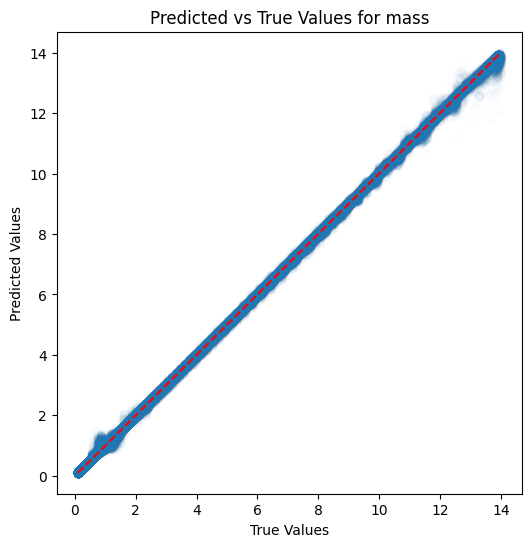

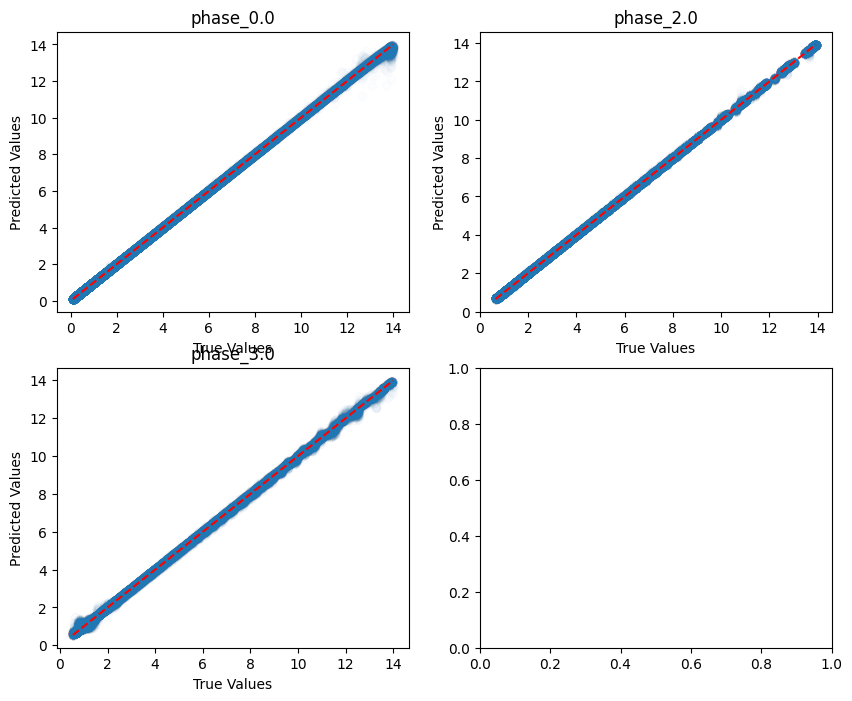

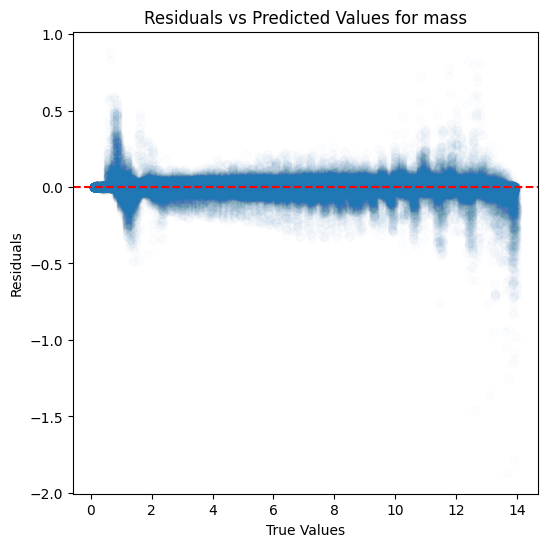

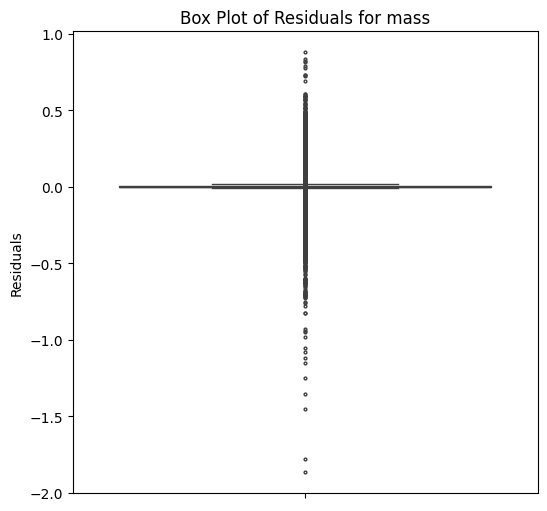

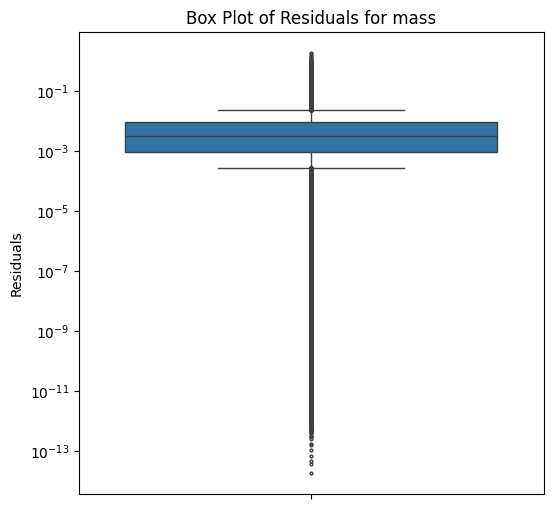

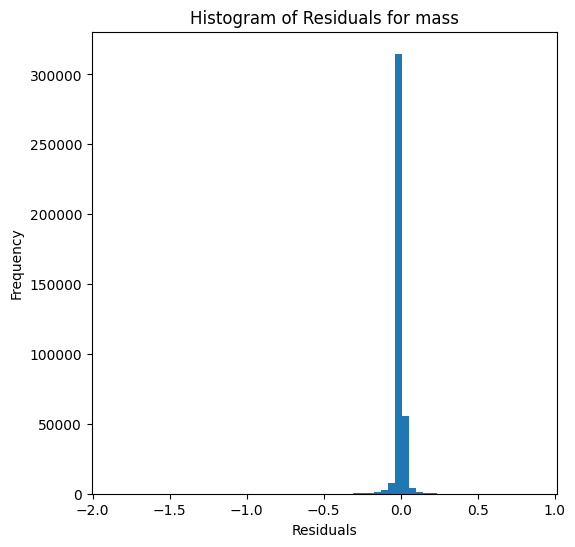

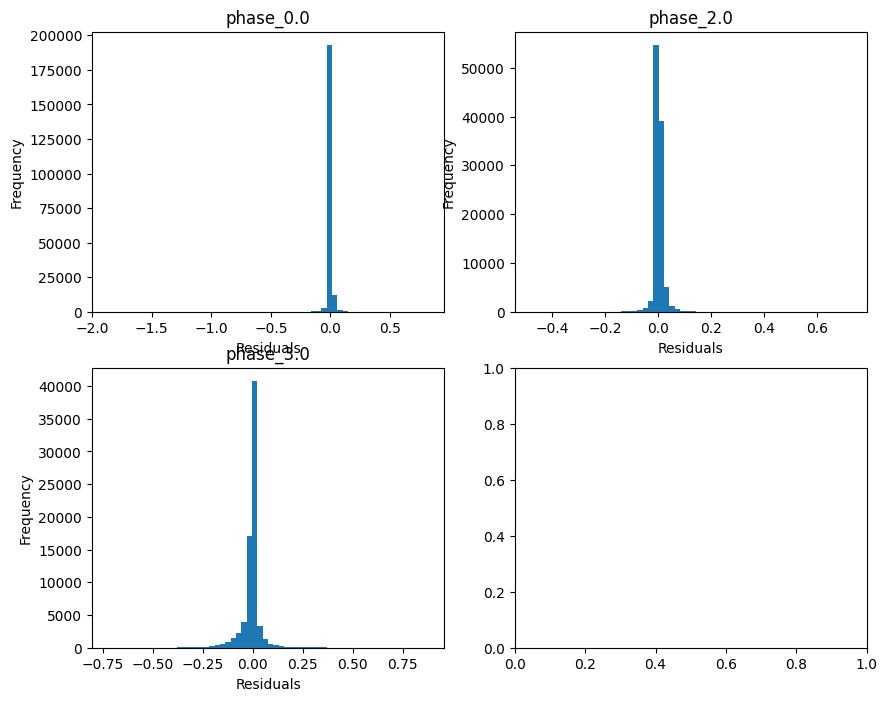

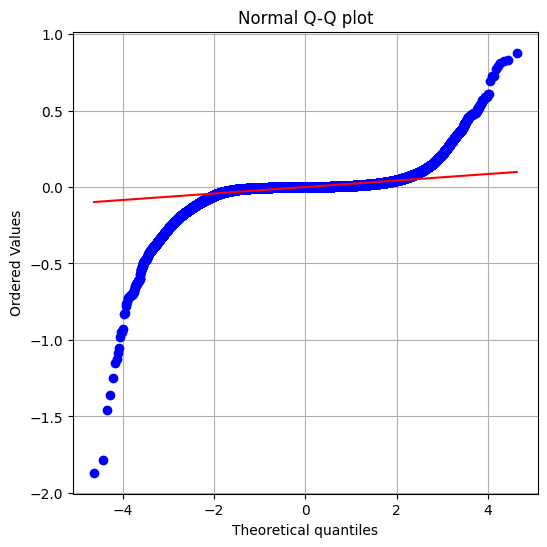

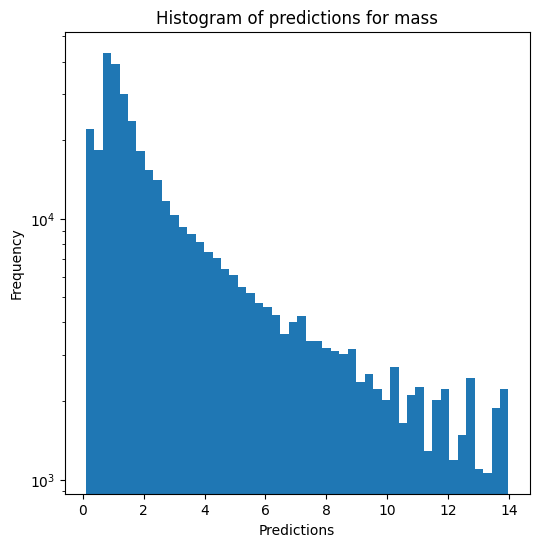

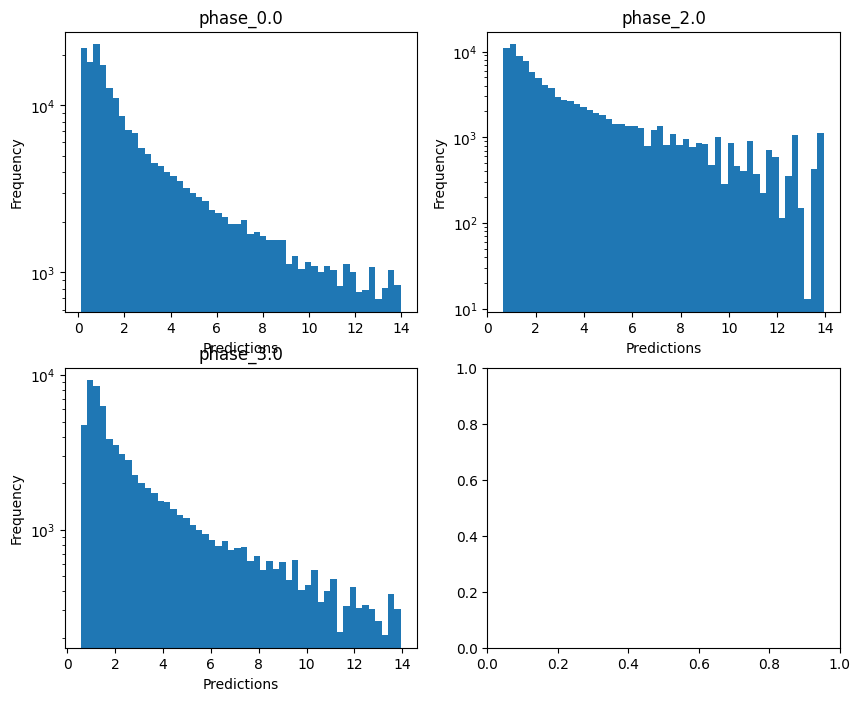


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999833701458357
  RMSE :  0.0017182353548236091
  MAE :  0.000985967110485586
  MedAE :  0.0005406379244093373
  CORR :  0.9999916973096302
  MAX_ER :  0.05745210723380012
  Percentiles : 
    75th percentile :  0.001184086143504709
    90th percentile :  0.0023509826885248393
    95th percentile :  0.0034157859732264475
    99th percentile :  0.00647501871891064

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999183303170665
  RMSE :  0.004457290435425607
  MAE :  0.003111129544255693
  MedAE :  0.0021369746574539106
  CORR :  0.9999610590727908
  MAX_ER :  0.051510413720083914
  Percentiles : 
    75th percentile :  0.004206546586891874
    90th percentile :  0.007138978242450779
    95th percentile :  0.009423850963503289
    99th percentile :  0.015015821141510092

radius resul

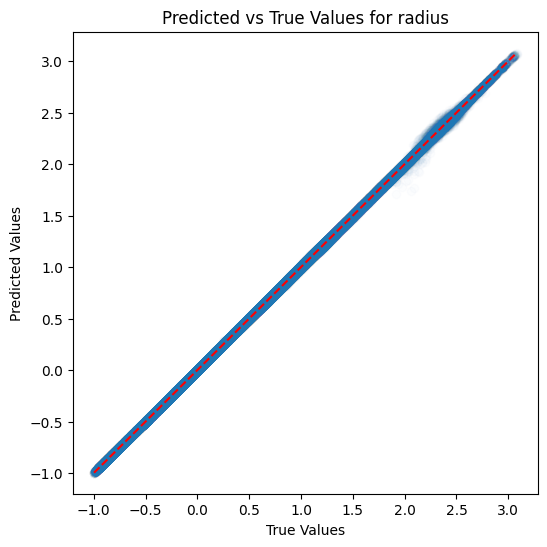

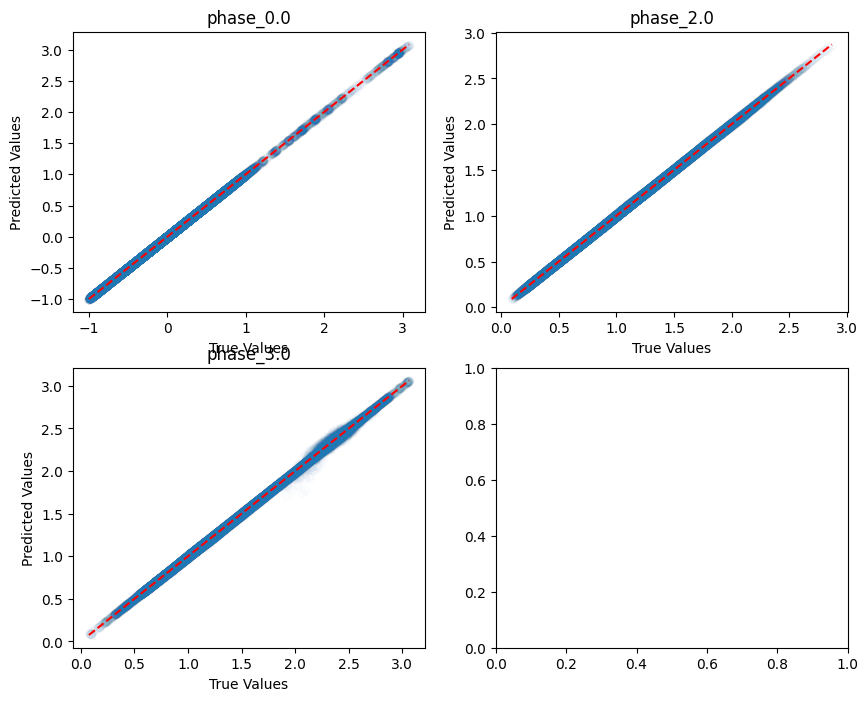

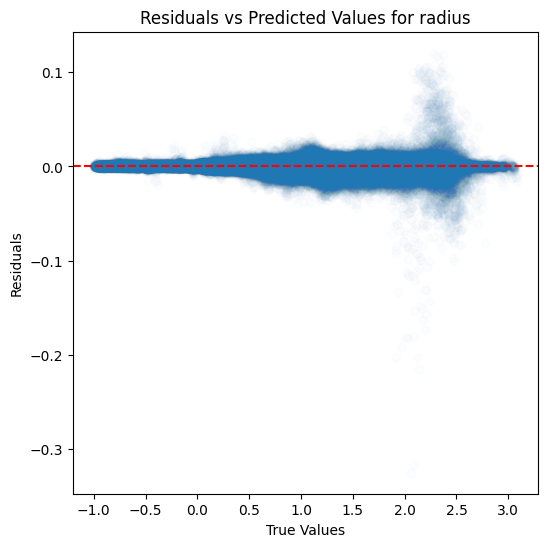

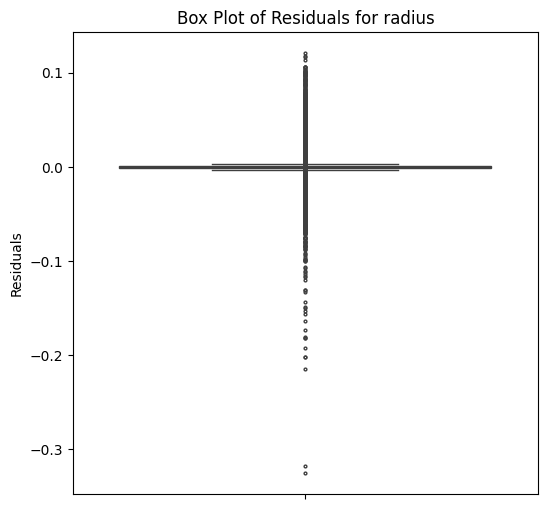

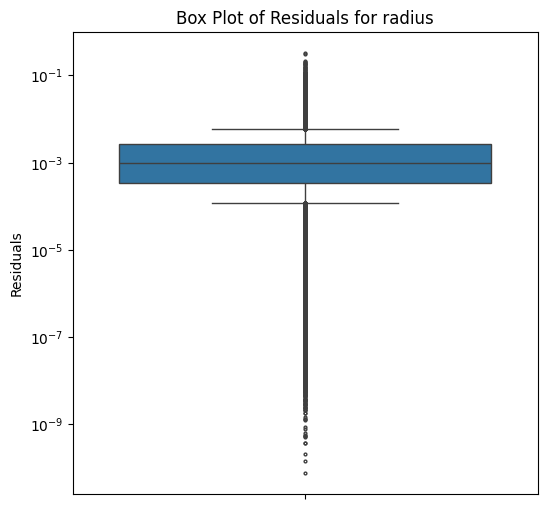

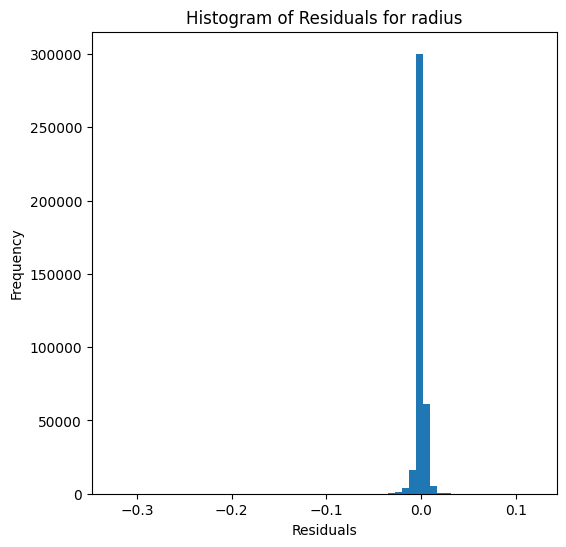

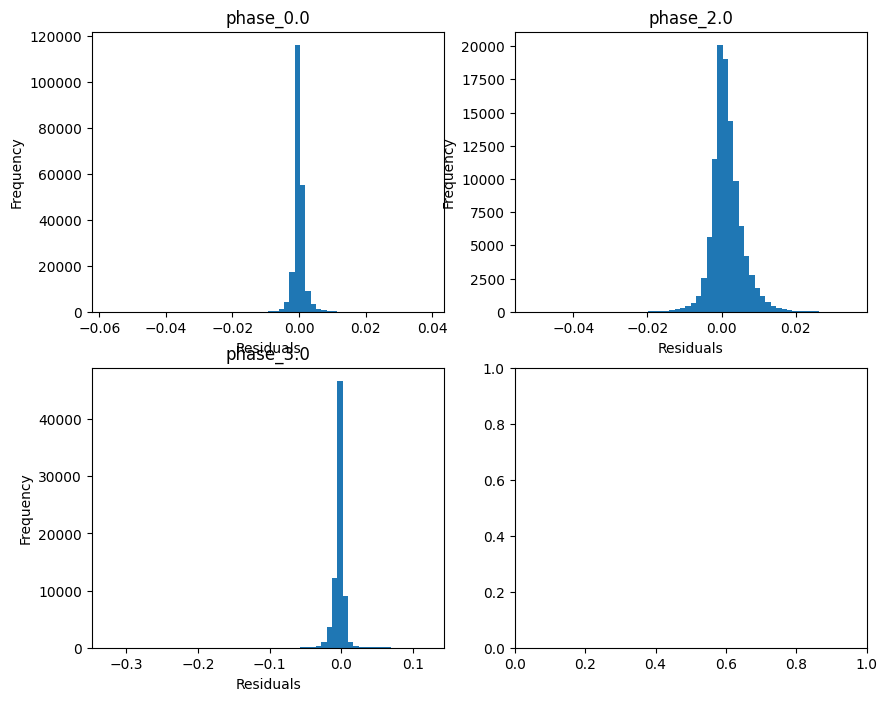

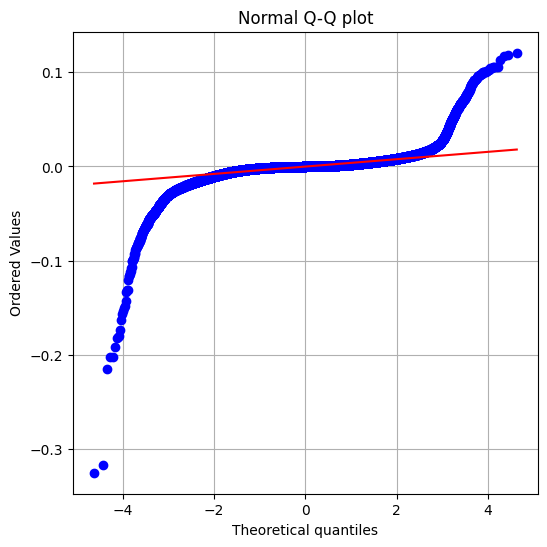

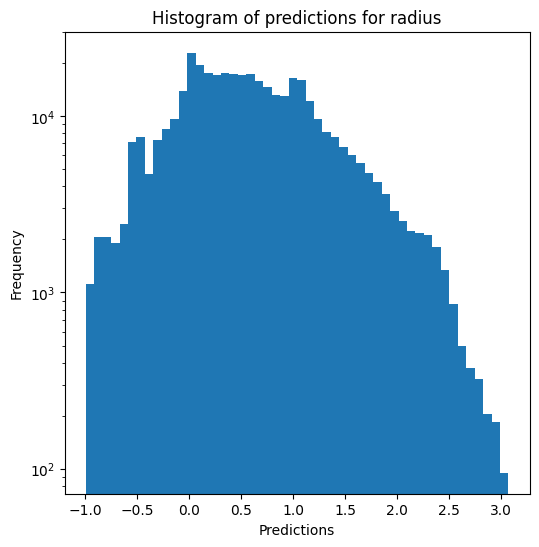

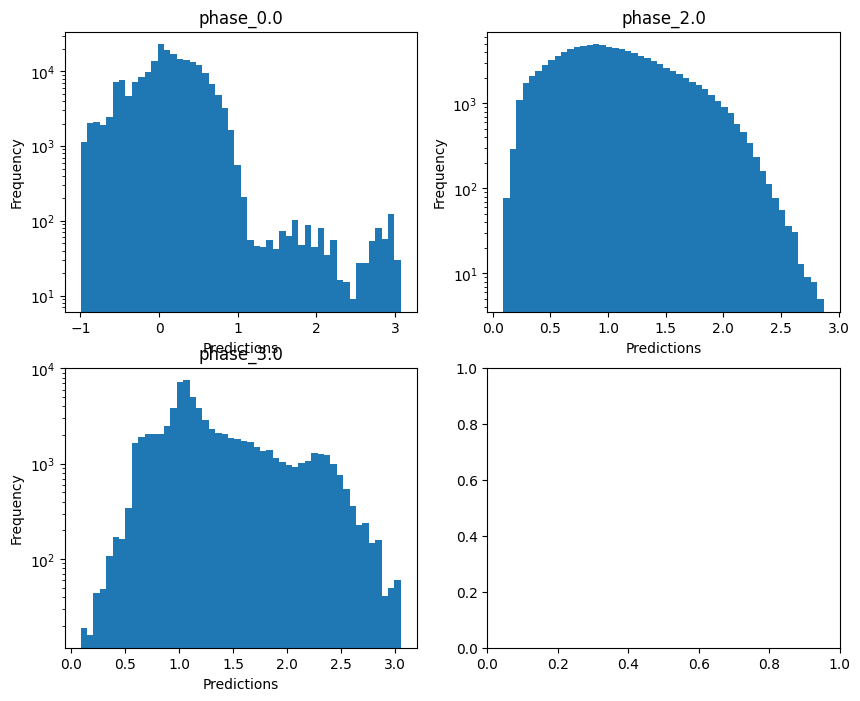

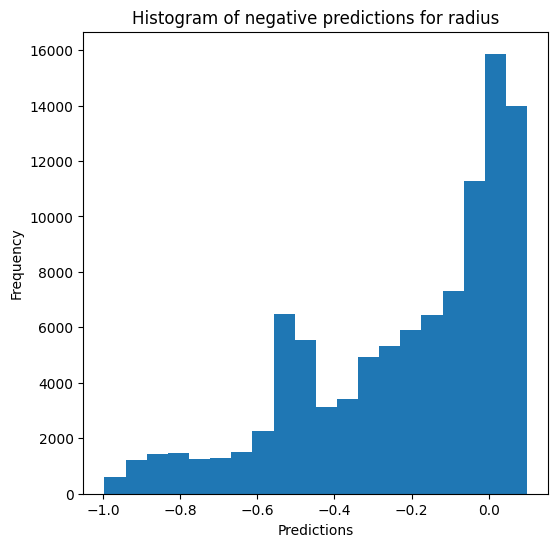

Saving predictions and results...


In [17]:
best_params_RF = {'n_jobs':10, 'n_estimators': 600, 'criterion': 'friedman_mse', 'max_depth': 100, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_leaf_nodes': None}

print(path_to_results)
dt_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="standard", **best_params_RF)

### K nearest neighbours

In [19]:
tag = "scale_standard_14"

#### Testing the uniform weights with brute strength

In [11]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_rmse = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   5.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.0s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.8s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   3.9s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.1s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.7s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.7s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   4.7s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.010095,0.003729,4.313899,0.538131,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-0.031492,-0.030489,-0.031590,-0.030400,-0.032003,-0.029796,-0.032347,-0.032245,-0.031391,-0.031743,-0.031350,0.000807,1,-0.012806,-0.012560,-0.012582,-0.012360,-0.012732,-0.012422,-0.012629,-0.012836,-0.012729,-0.012708,-0.012636,0.000149,1
1,0.011525,0.001171,4.739463,0.092966,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-0.036151,-0.034987,-0.036857,-0.034597,-0.036496,-0.034863,-0.036240,-0.037703,-0.035808,-0.036203,-0.035991,0.000913,2,-0.013941,-0.013625,-0.013637,-0.013285,-0.013800,-0.013531,-0.013693,-0.014039,-0.013786,-0.013598,-0.013693,0.000202,2
2,0.011996,0.001109,5.040987,0.251664,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-0.048431,-0.047196,-0.049587,-0.047859,-0.049198,-0.046682,-0.045928,-0.049748,-0.047385,-0.048304,-0.048032,0.001198,3,-0.018410,-0.017813,-0.017968,-0.017714,-0.018317,-0.017836,-0.017674,-0.018581,-0.018142,-0.017854,-0.018031,0.000298,3
3,0.012049,0.001572,5.091212,0.137944,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-0.059388,-0.057635,-0.059925,-0.058912,-0.059754,-0.056961,-0.055805,-0.061097,-0.058032,-0.058379,-0.058589,0.001478,4,-0.022456,-0.021719,-0.021859,-0.021782,-0.022371,-0.021868,-0.021547,-0.022649,-0.022100,-0.021844,-0.022020,0.000342,4
4,0.012421,0.001719,4.918014,0.147409,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-0.075137,-0.072644,-0.075537,-0.075001,-0.075338,-0.071984,-0.070949,-0.077044,-0.073885,-0.073813,-0.074133,0.001755,5,-0.027733,-0.026945,-0.027284,-0.027325,-0.027790,-0.027073,-0.026913,-0.028140,-0.027545,-0.027161,-0.027391,0.000382,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.03134989693216803


In [11]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["brute"]
            }

gscv_max_er = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit = True
)

gscv_max_er.fit(X_train_standard, y_train)
display_grid_search(gscv_max_er)

Fitting 10 folds for each of 5 candidates, totalling 50 fits
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   7.4s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.4s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.6s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ....algorithm=brute, n_neighbors=5, weights=uniform; total time=   4.5s
[CV] END ...algorithm=brute, n_neighbors=10, weights=uniform; total time=   5.1s
[CV] END ...algorithm=brute, n_neighbors=10, wei

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.009963,0.000974,4.877683,0.856311,brute,5,uniform,"{'algorithm': 'brute', 'n_neighbors': 5, 'weig...",-1.315603,-1.122283,-2.481753,-1.470688,-1.692798,-1.375417,-2.566355,-2.181780,-2.134654,-2.072978,-1.841431,0.485936,1
1,0.011919,0.002293,4.783705,0.183183,brute,10,uniform,"{'algorithm': 'brute', 'n_neighbors': 10, 'wei...",-1.465138,-1.336144,-3.431743,-2.798807,-2.060822,-1.718021,-2.308114,-2.716863,-2.661721,-2.441644,-2.293902,0.622571,2
2,0.011990,0.001403,4.649595,0.059906,brute,20,uniform,"{'algorithm': 'brute', 'n_neighbors': 20, 'wei...",-2.243645,-2.297611,-3.401733,-3.203245,-2.246009,-2.186969,-2.362313,-3.007558,-2.664308,-3.036097,-2.664949,0.435401,3
3,0.011759,0.001512,4.643488,0.072937,brute,30,uniform,"{'algorithm': 'brute', 'n_neighbors': 30, 'wei...",-2.463776,-2.672243,-3.688344,-3.480249,-2.900646,-2.608685,-2.443815,-3.053480,-2.779187,-3.435742,-2.952617,0.423178,4
4,0.011501,0.000729,4.803531,0.083275,brute,50,uniform,"{'algorithm': 'brute', 'n_neighbors': 50, 'wei...",-2.750482,-3.037379,-3.648863,-3.363000,-3.003979,-2.863299,-2.793657,-3.139523,-2.929823,-3.559172,-3.108918,0.299360,5


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}
Best score -1.8414310412309554


Best parameters {'algorithm': 'brute', 'n_neighbors': 5, 'weights': 'uniform'}

Best RMSE -0.03134989693216803 (average of both outputs)

Best MAX_ER -1.8414310412309554

#### Testing the uniform weights with algorithms

In [11]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_rmse = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.9s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   2.0s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.282427,0.046682,1.614509,0.114721,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.031500,-0.030486,-0.031591,-0.030407,-0.031997,-0.029800,-0.032351,-0.032250,-0.031390,-0.031738,-0.031351,0.000806,1,-0.012809,-0.012557,-0.012581,-0.012361,-0.012728,-0.012424,-0.012631,-0.012840,-0.012731,-0.012704,-0.012637,0.000150,1
1,0.279600,0.031896,1.561586,0.185282,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.036149,-0.034985,-0.036861,-0.034598,-0.036498,-0.034863,-0.036240,-0.037702,-0.035805,-0.036202,-0.035990,0.000913,16,-0.013941,-0.013624,-0.013641,-0.013288,-0.013802,-0.013532,-0.013689,-0.014039,-0.013784,-0.013596,-0.013694,0.000202,15
2,0.277124,0.038854,1.806721,0.179795,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.048431,-0.047198,-0.049588,-0.047861,-0.049198,-0.046677,-0.045927,-0.049748,-0.047383,-0.048303,-0.048031,0.001199,22,-0.018409,-0.017814,-0.017969,-0.017718,-0.018319,-0.017830,-0.017673,-0.018580,-0.018141,-0.017852,-0.018030,0.000298,22
3,0.258297,0.019081,2.192243,0.167652,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.059389,-0.057635,-0.059925,-0.058912,-0.059754,-0.056961,-0.055805,-0.061097,-0.058032,-0.058380,-0.058589,0.001478,33,-0.022457,-0.021719,-0.021859,-0.021782,-0.022372,-0.021869,-0.021547,-0.022650,-0.022100,-0.021846,-0.022020,0.000342,33
4,0.259329,0.018942,2.457349,0.239263,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.075137,-0.072644,-0.075536,-0.075000,-0.075338,-0.071984,-0.070950,-0.077044,-0.073884,-0.073812,-0.074133,0.001755,46,-0.027732,-0.026945,-0.027283,-0.027325,-0.027789,-0.027073,-0.026913,-0.028140,-0.027543,-0.027161,-0.027390,0.000382,42
5,0.226516,0.008377,1.720083,0.072954,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.031500,-0.030486,-0.031591,-0.030407,-0.031997,-0.029800,-0.032351,-0.032250,-0.031390,-0.031738,-0.031351,0.000806,1,-0.012809,-0.012557,-0.012581,-0.012361,-0.012728,-0.012424,-0.012631,-0.012840,-0.012731,-0.012704,-0.012637,0.000150,1
6,0.229725,0.012648,1.841203,0.095540,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.036149,-0.034985,-0.036861,-0.034598,-0.036498,-0.034863,-0.036238,-0.037702,-0.035805,-0.036202,-0.035990,0.000913,12,-0.013941,-0.013624,-0.013641,-0.013288,-0.013802,-0.013532,-0.013689,-0.014039,-0.013784,-0.013596,-0.013694,0.000202,12
7,0.233841,0.011858,2.162590,0.120535,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-0.048431,-0.047198,-0.049588,-0.047861,-0.049198,-0.046677,-0.045927,-0.049748,-0.047383,-0.048303,-0.048031,0.001199,21,-0.018409,-0.017814,-0.017969,-0.017718,-0.018319,-0.017830,-0.017673,-0.018580,-0.018141,-0.017852,-0.018030,0.000298,21
8,0.232866,0.012404,2.439844,0.110808,

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': 'uniform'}
Best score -0.03135097464015258


In [12]:
cv_params = {'n_neighbors' : [5, 10, 20, 30, 50],
             'weights' : ["uniform"],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 30, 50, 75, 100]
            }

gscv_max_err = GridSearchCV(KNeighborsRegressor(n_jobs = 5,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2, 
                         refit=True
)

gscv_max_err.fit(X_train_standard, y_train)
display_grid_search(gscv_max_err)

Fitting 10 folds for each of 50 candidates, totalling 500 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.3s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.3s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.3s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total time=   1.3s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, weights=uniform; total 

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.277767,0.036056,1.245470,0.149011,ball_tree,15,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.315603,-1.122283,-2.481753,-1.470688,-1.692798,-1.375417,-2.566355,-2.181780,-2.134654,-2.072978,-1.841431,0.485936,1
1,0.277631,0.029278,1.302298,0.033091,ball_tree,15,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.465138,-1.336144,-3.431743,-2.798807,-2.060822,-1.718021,-2.308114,-2.716863,-2.661721,-2.441644,-2.293902,0.622571,11
2,0.276757,0.030941,1.577982,0.106826,ball_tree,15,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.243645,-2.297611,-3.401733,-3.203245,-2.246009,-2.186969,-2.362313,-3.007558,-2.664308,-3.036097,-2.664949,0.435401,21
3,0.300912,0.056558,1.740786,0.048496,ball_tree,15,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.463776,-2.672243,-3.688344,-3.480249,-2.900646,-2.608685,-2.443815,-3.053480,-2.779187,-3.435742,-2.952617,0.423178,31
4,0.283846,0.035742,2.427653,0.395905,ball_tree,15,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-2.750482,-3.037379,-3.648863,-3.363000,-3.003979,-2.863299,-2.793657,-3.139523,-2.929823,-3.559172,-3.108918,0.299360,41
5,0.244090,0.038569,1.810788,0.127964,ball_tree,30,5,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-1.315603,-1.122283,-2.481753,-1.470688,-1.692798,-1.375417,-2.566355,-2.181780,-2.134654,-2.072978,-1.841431,0.485936,1
6,0.244017,0.032085,1.948362,0.107759,ball_tree,30,10,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-1.465138,-1.336144,-3.431743,-2.798807,-2.060822,-1.718021,-2.308114,-2.716863,-2.661721,-2.441644,-2.293902,0.622571,11
7,0.277035,0.076359,2.392733,0.090909,ball_tree,30,20,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-2.243645,-2.297611,-3.401733,-3.203245,-2.246009,-2.186969,-2.362313,-3.007558,-2.664308,-3.036097,-2.664949,0.435401,21
8,0.276188,0.073836,2.518588,0.182638,ball_tree,30,30,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-2.463776,-2.672243,-3.688344,-3.480249,-2.900646,-2.608685,-2.443815,-3.053480,-2.779187,-3.435742,-2.952617,0.423178,31
9,0.247100,0.041848,3.041042,0.158848,ball_tree,30,50,uniform,"{'algorithm': 'ball_tree', 'leaf_size': 30, 'n...",-2.750482,-3.037379,-3.648863,-3.363000,-3.003979,-2.863299,-2.793657,-3.139523,-2.929823,-3.559172,-3.108918,0.299360,41


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': 'uniform'}
Best score -1.8414310412309554


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': 'uniform'}

Best RMSE -0.03135097464015258

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'weights': 'uniform'}

Best score -1.8414310412309554

Algorithms give around the same results while being faster than brute.

#### Testing the distance weights with algorithms

In [11]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance", gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_rmse = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = scoring,
                         cv = 10,
                         verbose = 2,
                         refit="neg_root_mean_squared_error"
)

gscv_rmse.fit(X_train_standard, y_train)
display_grid_search(gscv_rmse)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
0,0.265106,0.038236,1.368273,0.089491,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.026350,-0.025510,-0.025140,-0.025848,-0.026905,-0.024807,-0.027623,-0.026851,-0.026370,-0.026253,-0.026166,0.000816,9,-0.009966,-0.009816,-0.009683,-0.009688,-0.009936,-0.009629,-0.009762,-0.009928,-0.009850,-0.009821,-0.009808,0.000111,3
1,0.246564,0.007962,1.367319,0.092537,ball_tree,15,5,1.0,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.031862,-0.030467,-0.031797,-0.031175,-0.031952,-0.030250,-0.032330,-0.032449,-0.031811,-0.031636,-0.031573,0.000694,45,-0.012826,-0.012502,-0.012513,-0.012364,-0.012701,-0.012378,-0.012480,-0.012832,-0.012655,-0.012632,-0.012588,0.000159,33
2,0.522763,0.043114,2.517837,0.241939,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.026631,-0.025600,-0.024976,-0.025518,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000919,3,-0.010029,-0.009840,-0.009698,-0.009699,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,9
3,0.508958,0.021944,2.567216,0.144960,ball_tree,15,5,1.3,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.031886,-0.030375,-0.031267,-0.030591,-0.031909,-0.030067,-0.032346,-0.032367,-0.031401,-0.031518,-0.031373,0.000764,39,-0.012826,-0.012474,-0.012457,-0.012331,-0.012731,-0.012421,-0.012495,-0.012834,-0.012627,-0.012626,-0.012582,0.000165,27
4,0.520474,0.036850,2.771462,0.186661,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.026417,-0.025678,-0.025105,-0.025484,-0.027272,-0.024700,-0.027710,-0.027006,-0.026245,-0.026344,-0.026196,0.000916,13,-0.010049,-0.009861,-0.009778,-0.009714,-0.010046,-0.009729,-0.009867,-0.010008,-0.009924,-0.009912,-0.009889,0.000117,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.261663,0.036022,1.263137,0.047907,kd_tree,100,50,1.3,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.071676,-0.069477,-0.072317,-0.071734,-0.072314,-0.069141,-0.068047,-0.073907,-0.070960,-0.070650,-0.071022,0.001659,127,-0.026941,-0.026165,-0.026496,-0.026538,-0.027074,-0.026296,-0.026210,-0.027408,-0.026808,-0.026342,-0.026628,0.000393,127
140,0.250398,0.021587,1.134943,0.060581,kd_tree,100,50,1.6,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.053653,-0.051763,-0.053536,-0.052822,-0.053878,-0.051168,-0.050745,-0.055523,-0.052459,-0.052884,-0.052843,0.001338,107,-0.018865,-0.018258,-0.018508,-0.018405,-0.018860,-0.018341,-0.018240,-0.019195,-0.018649,-0.018449,-0.018577,0.000295,89
141,0.261690,0.019109,1.097498,0.068055,kd_tree,100,50,1.6,<function gaussian at 0x0000017D20765260>,"{'

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}
Best score -0.026155613481379708


In [16]:
df = pd.DataFrame.from_dict(gscv_rmse.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_neg_root_mean_squared_error"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_neg_root_mean_squared_error,split1_test_neg_root_mean_squared_error,split2_test_neg_root_mean_squared_error,split3_test_neg_root_mean_squared_error,split4_test_neg_root_mean_squared_error,split5_test_neg_root_mean_squared_error,split6_test_neg_root_mean_squared_error,split7_test_neg_root_mean_squared_error,split8_test_neg_root_mean_squared_error,split9_test_neg_root_mean_squared_error,mean_test_neg_root_mean_squared_error,std_test_neg_root_mean_squared_error,rank_test_neg_root_mean_squared_error,split0_test_neg_mean_absolute_error,split1_test_neg_mean_absolute_error,split2_test_neg_mean_absolute_error,split3_test_neg_mean_absolute_error,split4_test_neg_mean_absolute_error,split5_test_neg_mean_absolute_error,split6_test_neg_mean_absolute_error,split7_test_neg_mean_absolute_error,split8_test_neg_mean_absolute_error,split9_test_neg_mean_absolute_error,mean_test_neg_mean_absolute_error,std_test_neg_mean_absolute_error,rank_test_neg_mean_absolute_error
50,0.414427,0.038254,6.690592,0.450218,ball_tree,100,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.026631,-0.025600,-0.024976,-0.025515,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000920,1,-0.010029,-0.009840,-0.009698,-0.009697,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,7
122,0.257977,0.011105,0.552631,0.027319,kd_tree,100,5,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.026631,-0.025600,-0.024976,-0.025515,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000920,1,-0.010029,-0.009840,-0.009698,-0.009697,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,7
26,0.423456,0.022828,4.622131,0.259514,ball_tree,50,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-0.026631,-0.025600,-0.024976,-0.025518,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000919,3,-0.010029,-0.009840,-0.009698,-0.009699,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,9
2,0.522763,0.043114,2.517837,0.241939,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-0.026631,-0.025600,-0.024976,-0.025518,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000919,3,-0.010029,-0.009840,-0.009698,-0.009699,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,9
74,0.324319,0.022039,0.206158,0.017706,kd_tree,15,5,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-0.026631,-0.025600,-0.024976,-0.025518,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000919,3,-0.010029,-0.009840,-0.009698,-0.009699,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,9
98,0.282486,0.027622,0.368120,0.022151,kd_tree,50,5,1.3,distance,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-0.026631,-0.025600,-0.024976,-0.025518,-0.027034,-0.024710,-0.027781,-0.026937,-0.026156,-0.026216,-0.026156,0.000919,3,-0.010029,-0.009840,-0.009698,-0.009699,-0.010005,-0.009688,-0.009816,-0.009971,-0.009856,-0.009851,-0.009845,0.000120,9
120,0.237988,0.011764,0.314176,0.053519,kd_tree,100,5,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-0.026349,-0.025510,-0.025140,-0.025846,-0.026905,-0.024807,-0.027623,-0.026851,-0.026370,-0.026253,-0.026165,0.000816,7,-0.009965,-0.009816,-0.009683,-0.009686,-0.009936,-0.009629,-0.009762,-0.009928,-0.009850,-0.009821,-0.009808,0.000111,1
48,0.199076,0.011435,3.483500,0.493379,ball_tree,100,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-0.026350,-0.025510,-0.025140,-0.025846,-0.026905,-0.024807,-0.027623,-0.026851,-0.026370,-0.026253,-0.026165,0.000816,8,-0.009966,-0.009816,-0.009683,-0.009686,-0.009936,-0.009629,-0.009762,-0.009928,-0.009850,-0.009821,-0.009808,0.000111,2
24,

In [12]:
cv_params = {'n_neighbors' : [5, 25, 50],
             'weights' : ["distance", gaussian],
             'algorithm' : ["ball_tree", "kd_tree"],
             'leaf_size' : [15, 50, 100],
             'p' : [1.0, 1.3, 1.6, 2.0]
            }

gscv_max_err = GridSearchCV(KNeighborsRegressor(n_jobs = 10,
                                             ),
                         param_grid = cv_params,
                         scoring = max_err_scorer,
                         cv = 10,
                         verbose = 2,
                         refit = True
)

gscv_max_err.fit(X_train_standard, y_train)
display_grid_search(gscv_max_err)

Fitting 10 folds for each of 144 candidates, totalling 1440 fits
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.5s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.4s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.7s
[CV] END algorithm=ball_tree, leaf_size=15, n_neighbors=5, p=1.0, weights=distance; total time=   1.6s
[CV] END

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.268639,0.031470,1.370978,0.063615,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.046526,-1.041714,-0.981683,-1.702198,-1.684661,-1.124757,-2.566286,-1.987471,-1.967561,-2.072632,-1.617549,0.517981,7
1,0.249301,0.028552,1.374642,0.094446,ball_tree,15,5,1.0,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.035626,-1.118941,-2.412590,-1.700655,-1.692287,-1.384997,-2.566354,-2.157708,-2.127672,-2.072609,-1.826944,0.500675,25
2,0.512069,0.042806,2.477764,0.159877,ball_tree,15,5,1.3,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.344530,-1.072299,-0.909035,-1.701753,-1.678588,-1.136381,-2.566301,-1.984596,-1.944887,-2.072912,-1.641128,0.495981,19
3,0.517542,0.042871,2.636186,0.194526,ball_tree,15,5,1.3,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.333316,-1.120374,-2.421803,-1.700611,-1.692226,-1.385461,-2.566354,-2.163747,-2.128734,-2.072897,-1.858552,0.461251,43
4,0.525418,0.067172,2.837533,0.254875,ball_tree,15,5,1.6,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.328057,-1.079703,-0.916301,-1.555047,-1.673399,-1.142206,-2.566313,-1.984059,-1.918715,-2.072914,-1.623671,0.492948,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,0.243366,0.009976,1.058339,0.068591,kd_tree,100,50,1.3,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-2.582174,-2.914624,-3.475599,-3.272457,-2.979809,-2.860135,-2.693704,-2.939782,-2.937811,-3.341405,-2.999750,0.268353,127
140,0.236141,0.009271,1.145480,0.067383,kd_tree,100,50,1.6,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-2.276253,-2.304439,-2.575600,-2.263053,-2.320240,-1.930835,-2.284376,-2.981565,-2.829586,-2.710187,-2.447613,0.301693,85
141,0.235468,0.011626,1.082695,0.090851,kd_tree,100,50,1.6,<function gaussian at 0x0000017D20765260>,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-2.603640,-2.929850,-3.491281,-3.271320,-2.991860,-2.864684,-2.715851,-3.036400,-2.933098,-3.424314,-3.026230,0.274786,133
142,0.227210,0.010602,0.591044,0.068512,kd_tree,100,50,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-2.312555,-2.371273,-2.696620,-2.350811,-2.324055,-1.900123,-2.266968,-3.077305,-2.819634,-2.720633,-2.483998,0.322382,91


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'p': 2.0, 'weights': 'distance'}
Best score -1.6086125118086116


In [14]:
df = pd.DataFrame.from_dict(gscv_max_err.cv_results_)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df.sort_values("rank_test_score"))

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algorithm,param_leaf_size,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
6,0.244081,0.014130,1.662828,0.070658,ball_tree,15,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.319936,-1.083758,-1.075169,-1.280851,-1.667611,-1.146337,-2.566326,-1.986402,-1.886750,-2.072987,-1.608613,0.481759,1
30,0.213156,0.019167,2.649542,0.255340,ball_tree,50,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-1.319936,-1.083758,-1.075169,-1.280851,-1.667611,-1.146337,-2.566326,-1.986402,-1.886750,-2.072987,-1.608613,0.481759,1
54,0.192267,0.010662,3.549449,0.491423,ball_tree,100,5,2.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-1.319936,-1.083758,-1.075169,-1.280851,-1.667611,-1.146337,-2.566326,-1.986402,-1.886750,-2.072987,-1.608613,0.481759,1
78,0.295872,0.007717,0.132521,0.007365,kd_tree,15,5,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-1.319936,-1.083758,-1.075169,-1.280851,-1.667611,-1.146337,-2.566326,-1.986402,-1.886750,-2.072987,-1.608613,0.481759,1
102,0.245594,0.009694,0.196854,0.022644,kd_tree,50,5,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 50, 'n_n...",-1.319936,-1.083758,-1.075169,-1.280851,-1.667611,-1.146337,-2.566326,-1.986402,-1.886750,-2.072987,-1.608613,0.481759,1
126,0.222181,0.006694,0.265244,0.042830,kd_tree,100,5,2.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 100, 'n_...",-1.319936,-1.083758,-1.075169,-1.280851,-1.667611,-1.146337,-2.566326,-1.986402,-1.886750,-2.072987,-1.608613,0.481759,1
48,0.190149,0.007631,3.292259,0.599696,ball_tree,100,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 100, '...",-1.046526,-1.041714,-0.981683,-1.702198,-1.684661,-1.124757,-2.566286,-1.987471,-1.967561,-2.072632,-1.617549,0.517981,7
24,0.206297,0.014537,2.028948,0.173313,ball_tree,50,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 50, 'n...",-1.046526,-1.041714,-0.981683,-1.702198,-1.684661,-1.124757,-2.566286,-1.987471,-1.967561,-2.072632,-1.617549,0.517981,7
72,0.295805,0.008035,0.158627,0.015160,kd_tree,15,5,1.0,distance,"{'algorithm': 'kd_tree', 'leaf_size': 15, 'n_n...",-1.046526,-1.041714,-0.981683,-1.702198,-1.684661,-1.124757,-2.566286,-1.987471,-1.967561,-2.072632,-1.617549,0.517981,7
0,0.268639,0.031470,1.370978,0.063615,ball_tree,15,5,1.0,distance,"{'algorithm': 'ball_tree', 'leaf_size': 15, 'n...",-1.046526,-1.041714,-0.981683,-1.702198,-1.684661,-1.124757,-2.566286,-1.987471,-1.967561,-2.072632,-1.617549,0.517981,7


Best parameters {'algorithm': 'ball_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.3, 'weights': 'distance'}

Best RMSE -0.026155613481379708 (average of both output)

Best parameters {'algorithm': 'ball_tree', 'leaf_size': 15, 'n_neighbors': 5, 'p': 2.0, 'weights': 'distance'}

Best MAX_ER -1.6086125118086116

Best parameters {'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'} is a good compromise between the two scores (7th best for both RMSE and MAX_ER)


#### Training the model with all the fine-tuned parameters and checking the results

../../../../../../results/model_A_partial/fine_tuned_models/

scale_standard_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9998300969467618
  RMSE :  0.04295894240551945
  MAE :  0.015148768076432862
  MedAE :  0.0036777846173947637
  CORR :  0.9999156620855871
  MAX_ER :  2.566285804129171
  Percentiles : 
    75th percentile :  0.012662536388147405
    90th percentile :  0.037169784858424045
    95th percentile :  0.06667177753357081
    99th percentile :  0.1724499647591932

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9998756585459273
  RMSE :  0.03621376645501981
  MAE :  0.01255988422870484
  MedAE :  0.0024441745096694945
  CORR :  0.9999385111804107
  MAX_ER :  0.8862990284311572
  Percentiles : 
    75th percentil

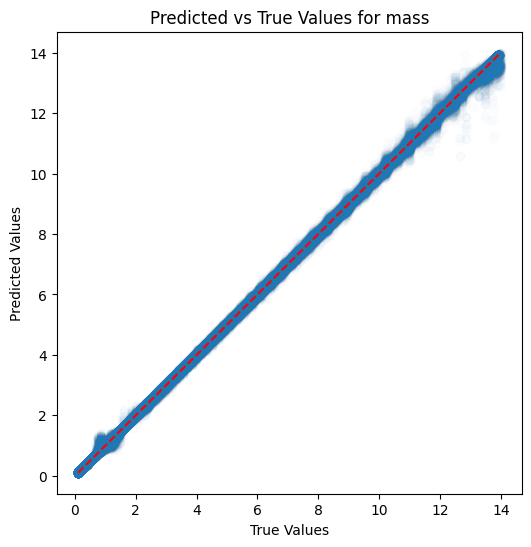

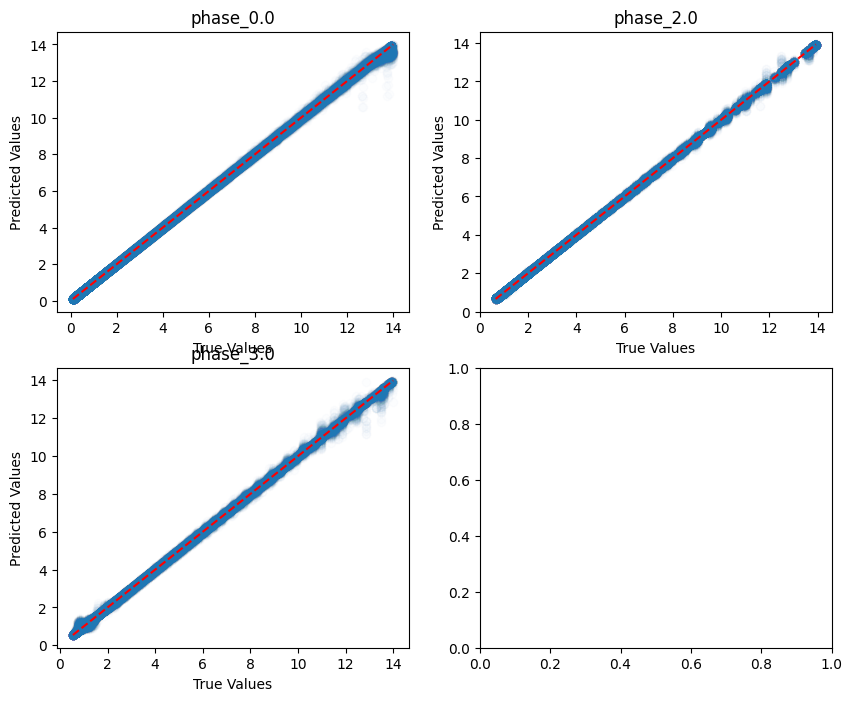

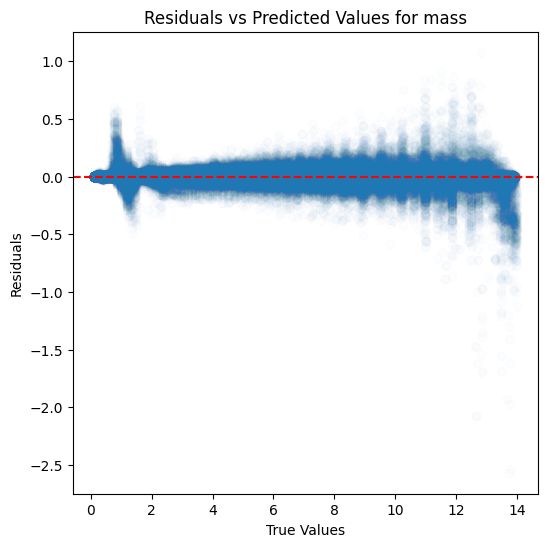

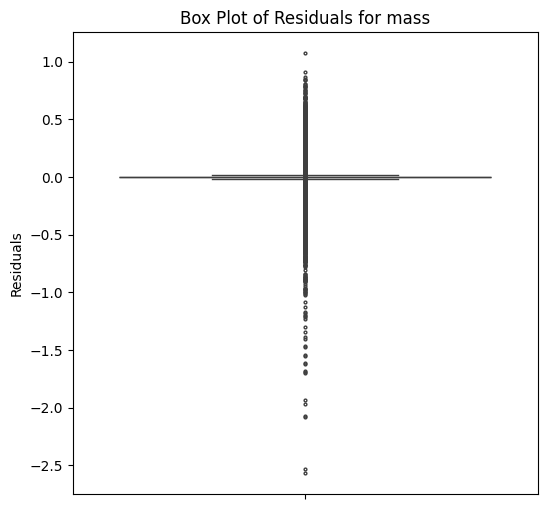

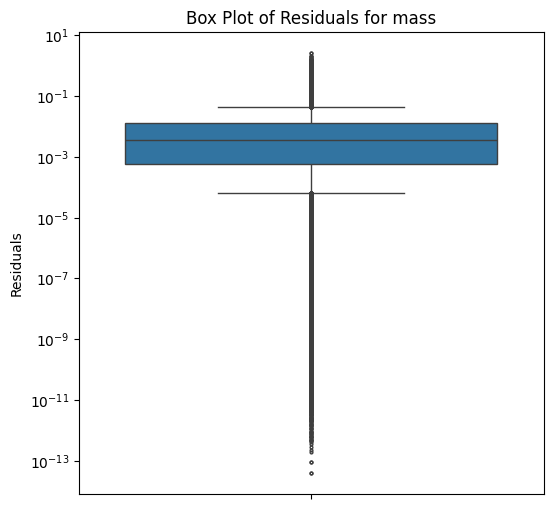

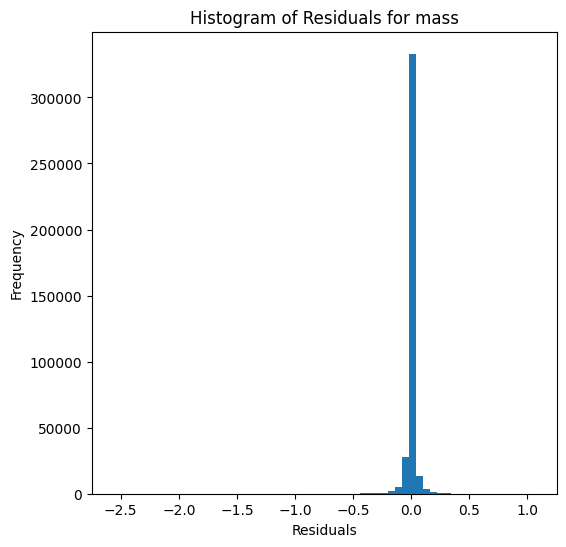

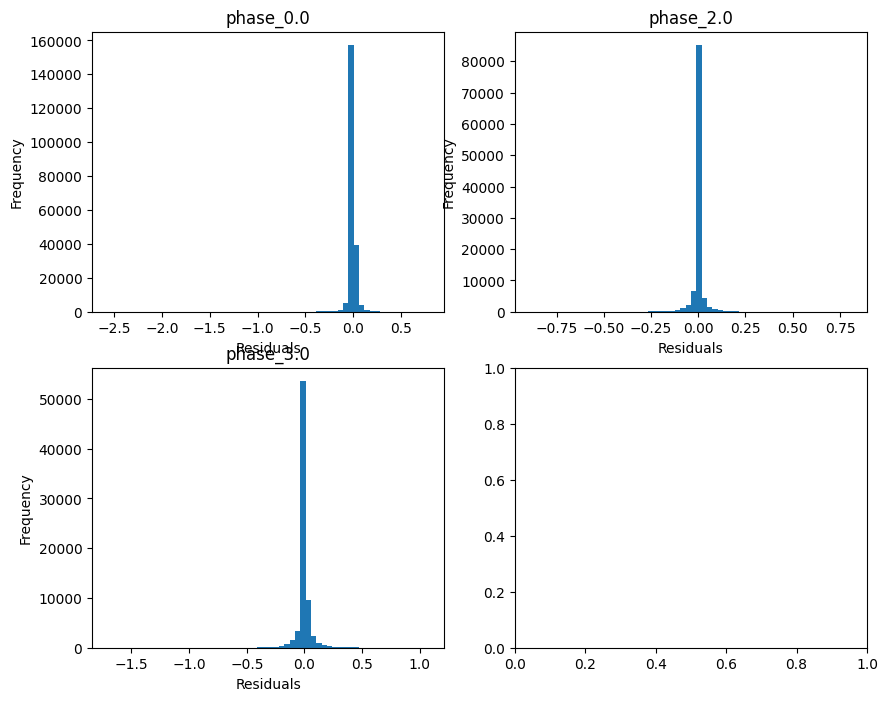

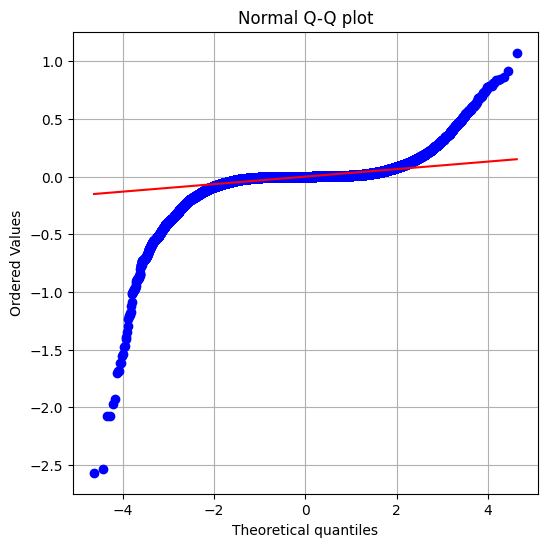

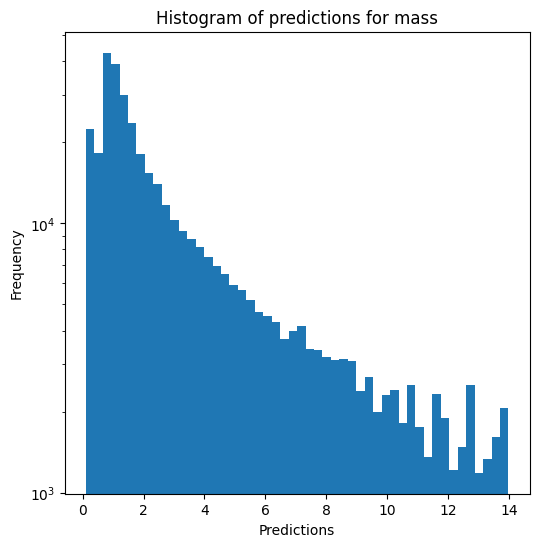

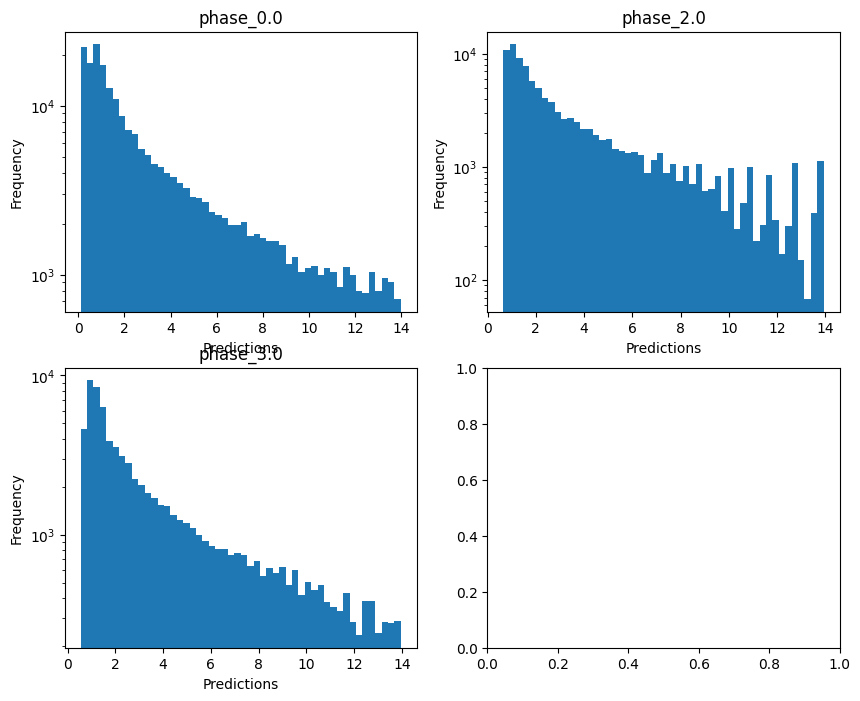


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.999932168844809
  RMSE :  0.0034698982773355455
  MAE :  0.002262827712955662
  MedAE :  0.0015318698312455359
  CORR :  0.9999662405274222
  MAX_ER :  0.06761673363345322
  Percentiles : 
    75th percentile :  0.0027408846518852115
    90th percentile :  0.004994407336114504
    95th percentile :  0.007019133535258053
    99th percentile :  0.013034579472642202

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9998973683651688
  RMSE :  0.004716432497269814
  MAE :  0.0034845573669680047
  MedAE :  0.002514990685943075
  CORR :  0.9999488635226403
  MAX_ER :  0.05166699205919212
  Percentiles : 
    75th percentile :  0.004447362454444409
    90th percentile :  0.007634421452235005
    95th percentile :  0.00996151872220861
    99th percentile :  0.014902372021778678

radius results 

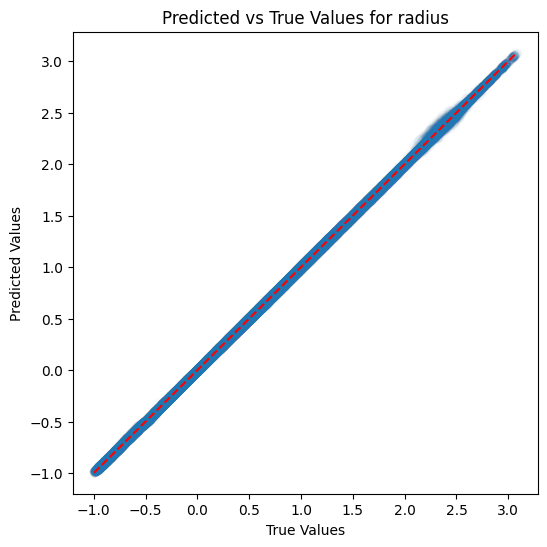

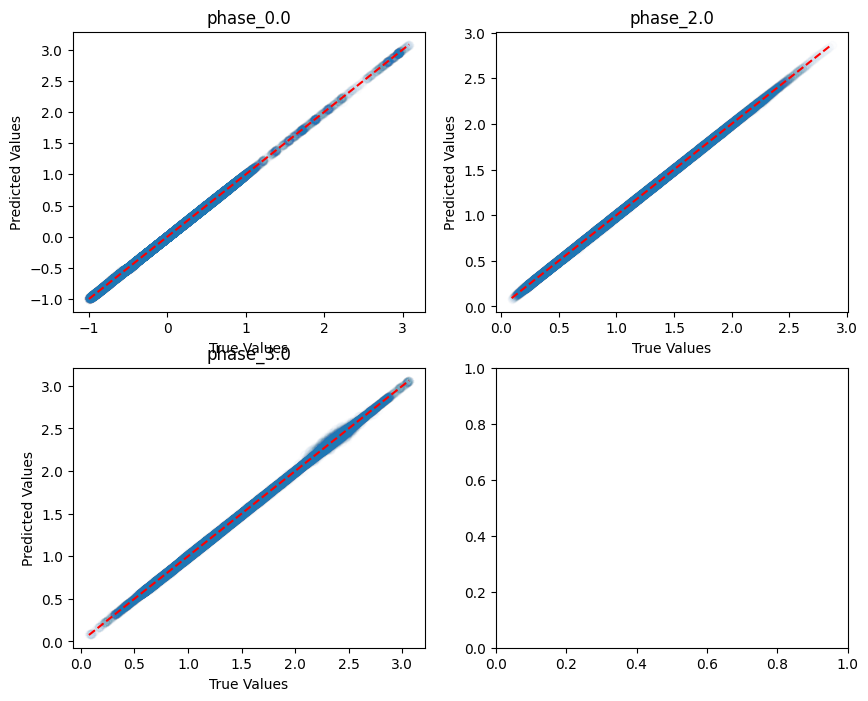

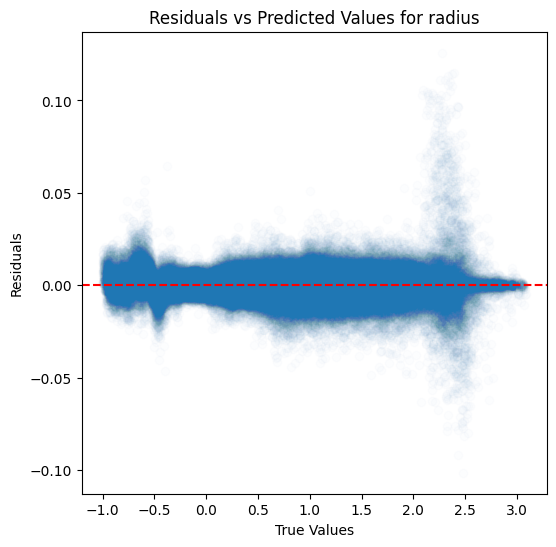

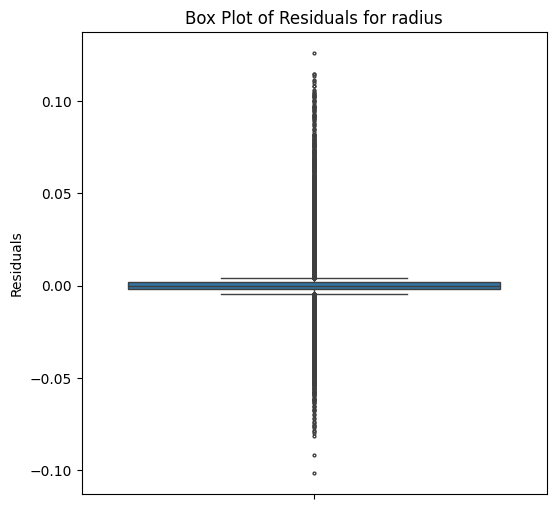

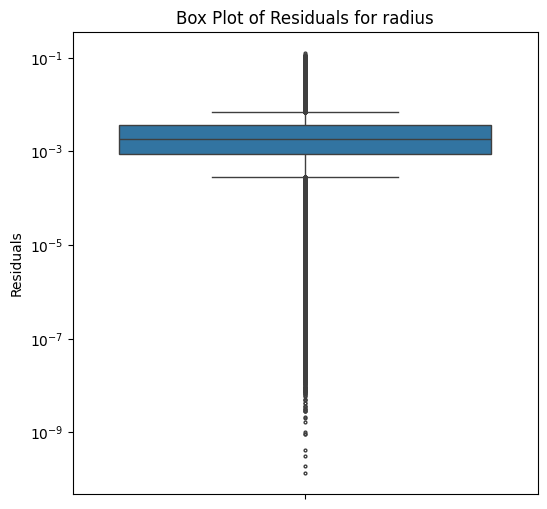

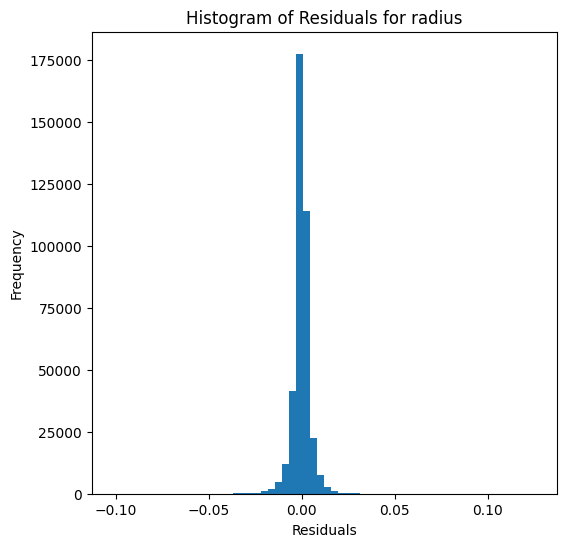

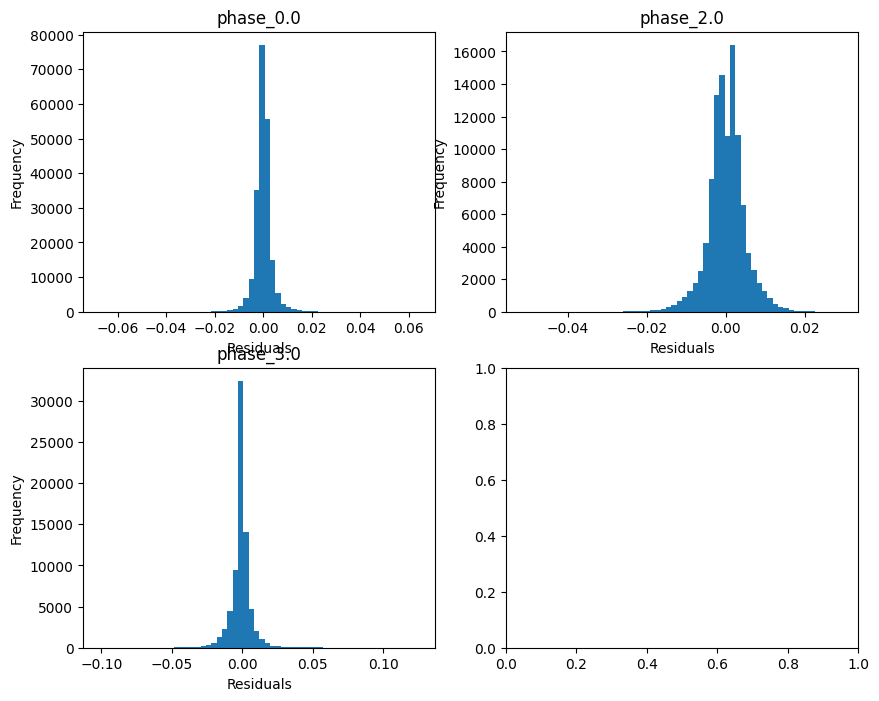

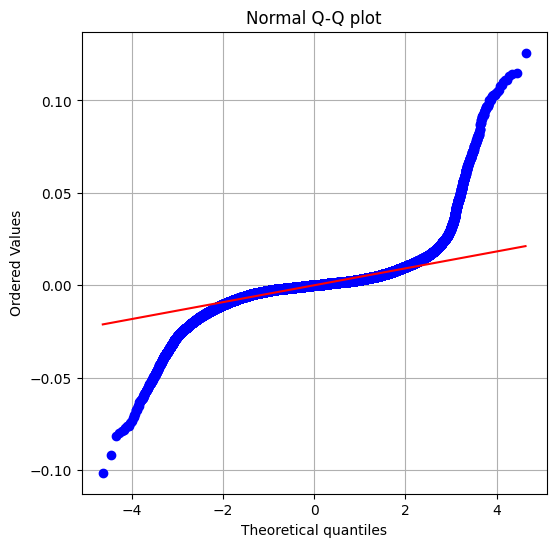

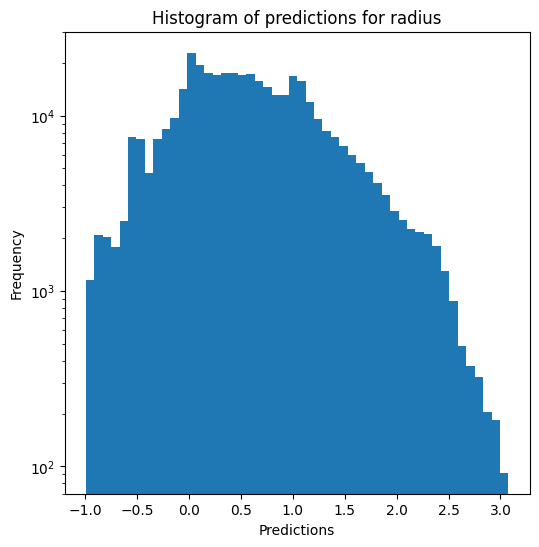

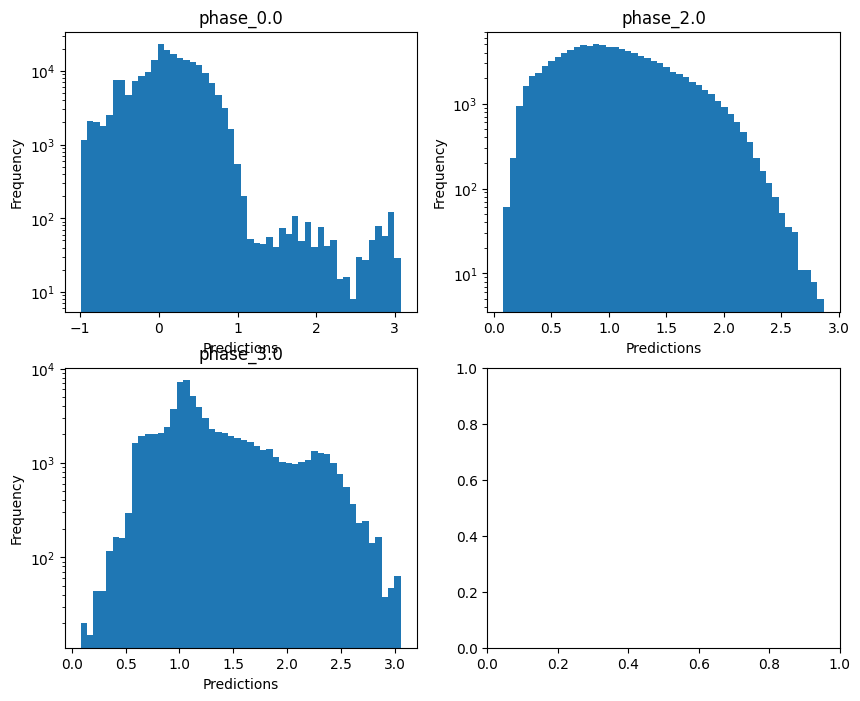

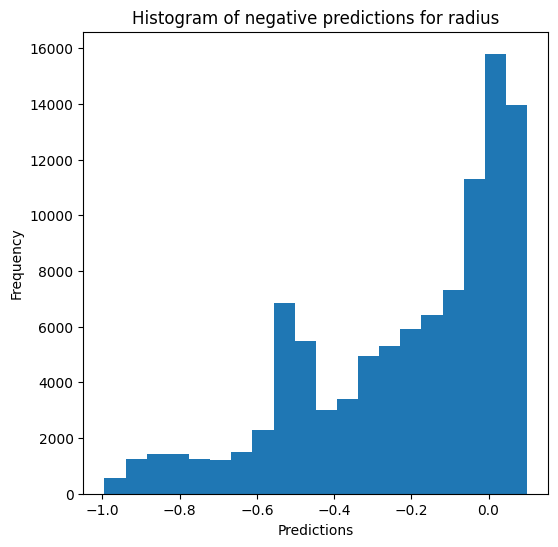

Saving predictions and results...


In [22]:
best_params_KNN = {'n_jobs':10, 'algorithm': 'kd_tree', 'leaf_size': 100, 'n_neighbors': 5, 'p': 1.0, 'weights': 'distance'}

print(path_to_results)
dt_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)
dt_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name="standard", **best_params_KNN)